In [1]:
import onnx
import cv2
import numpy as np
import onnxruntime as ort
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
model = onnx.load("models\\insightface\\buffalo_sc\\det_500m.onnx") # load ONNX model
graph = model.graph

first_conv_output = None

node_lst = []
for node in graph.node:
    if node.op_type == 'Conv':

        print("First Conv output name:", node)
        node_lst.append(node)

        if len(node_lst) == 2: # For first conv layer (insightface is 2nd)
            break

First Conv output name: input: "input.1"
input: "546"
input: "548"
output: "286"
name: "Conv_0"
op_type: "Conv"
attribute {
  name: "dilations"
  ints: 1
  ints: 1
  type: INTS
}
attribute {
  name: "group"
  i: 1
  type: INT
}
attribute {
  name: "kernel_shape"
  ints: 3
  ints: 3
  type: INTS
}
attribute {
  name: "pads"
  ints: 1
  ints: 1
  ints: 1
  ints: 1
  type: INTS
}
attribute {
  name: "strides"
  ints: 2
  ints: 2
  type: INTS
}

First Conv output name: input: "288"
input: "550"
input: "552"
output: "289"
name: "Conv_3"
op_type: "Conv"
attribute {
  name: "dilations"
  ints: 1
  ints: 1
  type: INTS
}
attribute {
  name: "group"
  i: 16
  type: INT
}
attribute {
  name: "kernel_shape"
  ints: 3
  ints: 3
  type: INTS
}
attribute {
  name: "pads"
  ints: 1
  ints: 1
  ints: 1
  ints: 1
  type: INTS
}
attribute {
  name: "strides"
  ints: 1
  ints: 1
  type: INTS
}



In [ ]:
# Select first output conv layer (insightface first output is 2nd Conv node)
first_output_node = node_lst[1]
first_conv_output = first_output_node.output[0]

In [4]:
graph.output.clear()

In [5]:
new_output = onnx.ValueInfoProto()
new_output.name = first_conv_output
graph.output.append(new_output)

name: "289"

In [6]:
# Save modified model
onnx.save(model, "det_500m_first_conv.onnx")

In [7]:
# Process image
def preprocess(image_path, size):
    img = cv2.imread(image_path)

    if img is None:
        raise ValueError("Image not found")

    img = cv2.resize(img, size)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = img.astype(np.float32) / 255.0
    img = np.transpose(img, (2, 0, 1))  # HWC → CHW
    img = np.expand_dims(img, axis=0)

    return img

In [8]:
session = ort.InferenceSession("det_500m_first_conv.onnx")

input_name = session.get_inputs()[0].name

# Get image size
image_path = 'images\\t1.jpg'
with Image.open(image_path) as img:
    w, h = img.size

input_data = preprocess(image_path, (w,h))

output = session.run(None, {input_name: input_data})[0]

print("Output shape:", output.shape)

Output shape: (1, 16, 443, 640)


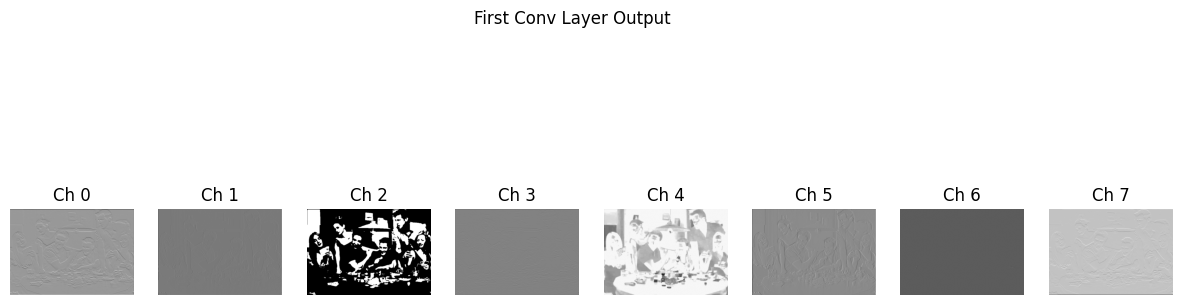

In [10]:
# Plot image output from first conv layer
# output shape: (1, channels, height, width)
feature_maps = output[0]

num_channels = min(8, feature_maps.shape[0])

fig, axes = plt.subplots(1, num_channels, figsize=(15, 5))

for i in range(num_channels):
    fm = feature_maps[i]

    # Normalize
    fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-6)

    axes[i].imshow(fm, cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f'Ch {i}')

plt.suptitle("First Conv Layer Output")
plt.show()